# Market Basket Analysis & NLP Product Classification
## Phan tich luat ket hop (Association Rules) + NLP phan loai san pham

**Dataset:** Sales Data.csv (185,950 ban ghi, 19 san pham, 9 thanh pho, nam 2019)

**Muc tieu:**
1. Su dung NLP de tu dong phan loai 19 san pham thanh Category / SubCategory
2. Thuc hien Market Basket Analysis bang Apriori Algorithm
3. Phan tich o ca 2 cap: product-level va category-level

---
## Phan 1: Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries loaded successfully!')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries loaded successfully!


In [2]:
df = pd.read_csv('../data/raw/Sales Data.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDtypes:')
print(df.dtypes)
print(f'\nNull values:')
print(df.isnull().sum())
print(f'\nFirst 5 rows:')
df.head()

Shape: (185950, 11)

Columns: ['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour']

Dtypes:
Unnamed: 0            int64
Order ID              int64
Product                 str
Quantity Ordered      int64
Price Each          float64
Order Date              str
Purchase Address        str
Month                 int64
Sales               float64
City                    str
Hour                  int64
dtype: object

Null values:
Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

First 5 rows:


,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['City'] = df['City'].str.strip()

print(f'Tong so don hang (unique Order ID): {df["Order ID"].nunique():,}')
print(f'So loai san pham: {df["Product"].nunique()}')
print(f'So thanh pho: {df["City"].nunique()}')
print(f'Thoi gian: {df["Order Date"].min()} -> {df["Order Date"].max()}')
print(f'Tong doanh thu: ${df["Sales"].sum():,.2f}')

Tong so don hang (unique Order ID): 178,437
So loai san pham: 19
So thanh pho: 9
Thoi gian: 2019-01-01 03:07:00 -> 2020-01-01 05:13:00
Tong doanh thu: $34,492,035.97


---
## Phan 2: NLP — Phan loai san pham thanh Category / SubCategory

**Approach:**
1. Tokenize ten san pham bang NLTK
2. Keyword extraction & rule-based classification
3. TF-IDF Vectorization + Cosine Similarity de validate nhom

In [4]:
# Lay danh sach san pham unique
products = df['Product'].unique()
print(f'Danh sach {len(products)} san pham:\n')

# Tokenize tung ten san pham
stop_words = set(stopwords.words('english'))
product_tokens = {}

for p in sorted(products):
    tokens = word_tokenize(p.lower())
    # Loc bo stopwords va ky tu dac biet
    filtered = [t for t in tokens if t.isalpha() and t not in stop_words]
    product_tokens[p] = filtered
    print(f'  {p:40s} -> tokens: {filtered}')

print(f'\nTong so san pham: {len(product_tokens)}')

Danh sach 19 san pham:

  20in Monitor                             -> tokens: ['monitor']
  27in 4K Gaming Monitor                   -> tokens: ['gaming', 'monitor']
  27in FHD Monitor                         -> tokens: ['fhd', 'monitor']
  34in Ultrawide Monitor                   -> tokens: ['ultrawide', 'monitor']
  AA Batteries (4-pack)                    -> tokens: ['aa', 'batteries']
  AAA Batteries (4-pack)                   -> tokens: ['aaa', 'batteries']
  Apple Airpods Headphones                 -> tokens: ['apple', 'airpods', 'headphones']
  Bose SoundSport Headphones               -> tokens: ['bose', 'soundsport', 'headphones']
  Flatscreen TV                            -> tokens: ['flatscreen', 'tv']
  Google Phone                             -> tokens: ['google', 'phone']
  LG Dryer                                 -> tokens: ['lg', 'dryer']
  LG Washing Machine                       -> tokens: ['lg', 'washing', 'machine']
  Lightning Charging Cable                 -> token

In [5]:
# Dinh nghia keyword taxonomy cho phan loai
# Moi entry: keyword -> (Category, SubCategory)
keyword_taxonomy = {
    # Accessories
    'batteries': ('Accessories', 'Batteries'),
    'battery':   ('Accessories', 'Batteries'),
    'cable':     ('Accessories', 'Cables'),
    'charging':  ('Accessories', 'Cables'),
    
    # Audio
    'headphones': ('Audio', 'Headphones'),
    'airpods':    ('Audio', 'Headphones'),
    'soundsport': ('Audio', 'Headphones'),
    
    # Electronics - Monitors
    'monitor':  ('Electronics', 'Monitors'),
    
    # Electronics - Phones
    'phone':  ('Electronics', 'Phones'),
    'iphone': ('Electronics', 'Phones'),
    
    # Electronics - Laptops
    'laptop':   ('Electronics', 'Laptops'),
    'macbook':  ('Electronics', 'Laptops'),
    'thinkpad': ('Electronics', 'Laptops'),
    
    # Electronics - TVs
    'tv':         ('Electronics', 'TVs'),
    'flatscreen': ('Electronics', 'TVs'),
    
    # Home Appliances
    'washing': ('Home Appliances', 'Laundry'),
    'dryer':   ('Home Appliances', 'Laundry'),
    'machine': ('Home Appliances', 'Laundry'),
}

print('Keyword taxonomy defined:')
print(f'  {len(keyword_taxonomy)} keywords -> {len(set(keyword_taxonomy.values()))} (Category, SubCategory) groups')

Keyword taxonomy defined:
  18 keywords -> 8 (Category, SubCategory) groups


In [6]:
# Rule-based NLP classification: match tokens voi keyword taxonomy
def classify_product(product_name, tokens, taxonomy):
    """Phan loai san pham dua tren token matching voi keyword taxonomy."""
    matches = []
    for token in tokens:
        if token in taxonomy:
            matches.append(taxonomy[token])
    
    if matches:
        # Uu tien category xuat hien nhieu nhat
        from collections import Counter
        most_common = Counter(matches).most_common(1)[0][0]
        return most_common
    
    return ('Unknown', 'Unknown')

# Ap dung classification
classification = {}
for product, tokens in product_tokens.items():
    cat, subcat = classify_product(product, tokens, keyword_taxonomy)
    classification[product] = {'Category': cat, 'SubCategory': subcat}

# Hien thi ket qua
class_df = pd.DataFrame(classification).T
class_df.index.name = 'Product'
print('=== KET QUA PHAN LOAI NLP ===')
print()
for cat in sorted(class_df['Category'].unique()):
    print(f'\n[{cat}]')
    subset = class_df[class_df['Category'] == cat]
    for subcat in sorted(subset['SubCategory'].unique()):
        prods = subset[subset['SubCategory'] == subcat].index.tolist()
        print(f'  {subcat}:')
        for p in prods:
            print(f'    - {p}')

# Kiem tra khong co Unknown
unknown = class_df[class_df['Category'] == 'Unknown']
if len(unknown) > 0:
    print(f'\n⚠ {len(unknown)} san pham KHONG phan loai duoc: {unknown.index.tolist()}')
else:
    print(f'\n✓ Tat ca {len(class_df)} san pham da duoc phan loai thanh cong!')

=== KET QUA PHAN LOAI NLP ===


[Accessories]
  Batteries:
    - AA Batteries (4-pack)
    - AAA Batteries (4-pack)
  Cables:
    - Lightning Charging Cable
    - USB-C Charging Cable

[Audio]
  Headphones:
    - Apple Airpods Headphones
    - Bose SoundSport Headphones
    - Wired Headphones

[Electronics]
  Laptops:
    - Macbook Pro Laptop
    - ThinkPad Laptop
  Monitors:
    - 20in Monitor
    - 27in 4K Gaming Monitor
    - 27in FHD Monitor
    - 34in Ultrawide Monitor
  Phones:
    - Google Phone
    - Vareebadd Phone
    - iPhone
  TVs:
    - Flatscreen TV

[Home Appliances]
  Laundry:
    - LG Dryer
    - LG Washing Machine

✓ Tat ca 19 san pham da duoc phan loai thanh cong!


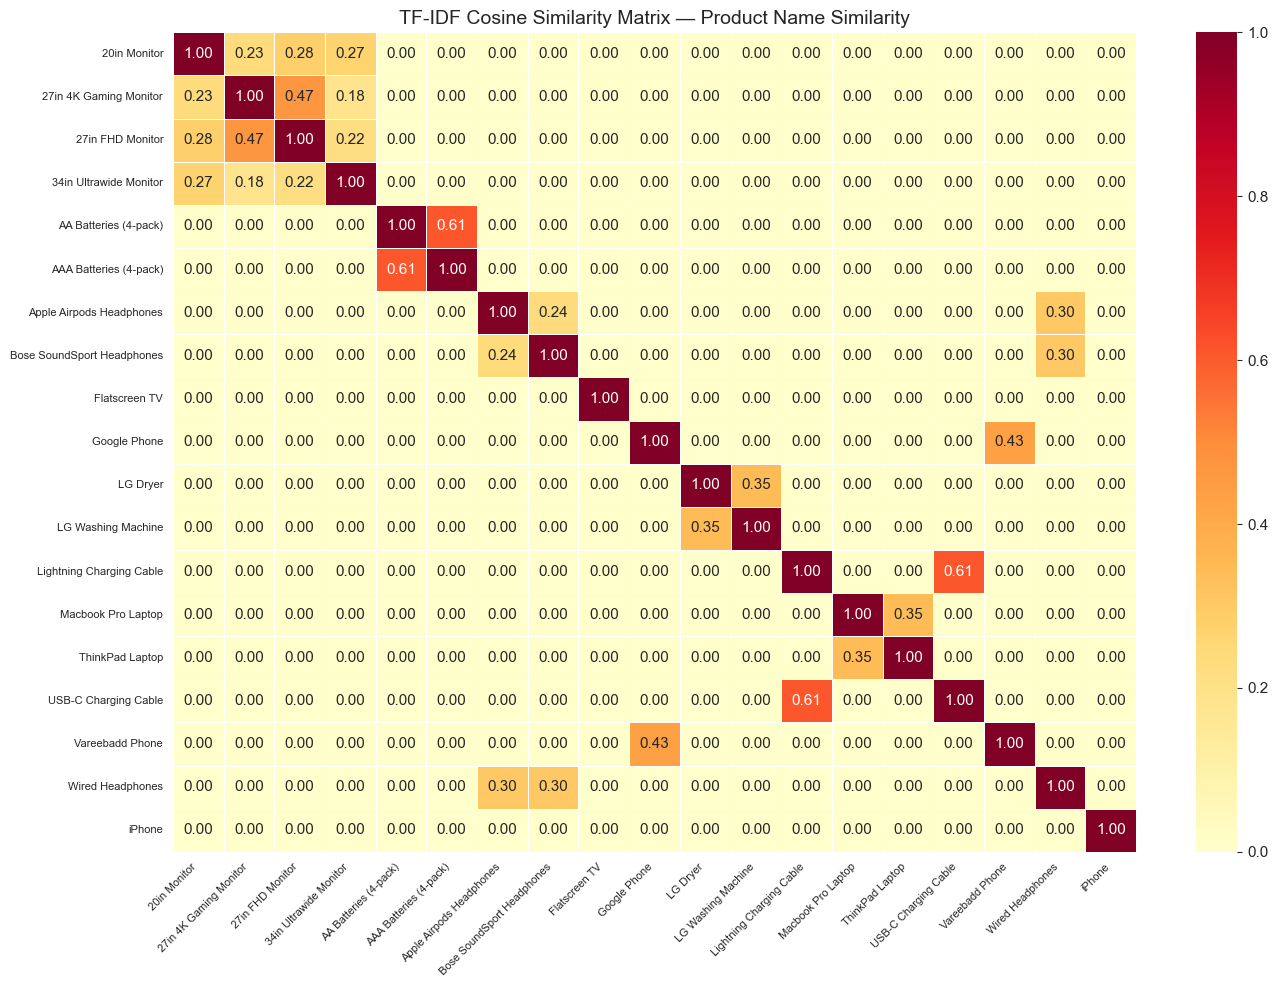


Cac cap san pham co do tuong dong cao (> 0.3):
  27in 4K Gaming Monitor                   <-> 27in FHD Monitor                         = 0.470
  AA Batteries (4-pack)                    <-> AAA Batteries (4-pack)                   = 0.606
  Apple Airpods Headphones                 <-> Wired Headphones                         = 0.302
  Bose SoundSport Headphones               <-> Wired Headphones                         = 0.302
  Google Phone                             <-> Vareebadd Phone                          = 0.435
  LG Dryer                                 <-> LG Washing Machine                       = 0.348
  Lightning Charging Cable                 <-> USB-C Charging Cable                     = 0.606
  Macbook Pro Laptop                       <-> ThinkPad Laptop                          = 0.348


In [7]:
# TF-IDF Vectorization & Cosine Similarity de validate nhom
tfidf = TfidfVectorizer(analyzer='word', stop_words='english')
tfidf_matrix = tfidf.fit_transform(sorted(products))

# Ma tran tuong dong cosine
cos_sim = cosine_similarity(tfidf_matrix)
sim_df = pd.DataFrame(cos_sim, index=sorted(products), columns=sorted(products))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            xticklabels=True, yticklabels=True)
ax.set_title('TF-IDF Cosine Similarity Matrix — Product Name Similarity', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('\nCac cap san pham co do tuong dong cao (> 0.3):')
for i in range(len(sim_df)):
    for j in range(i+1, len(sim_df)):
        if sim_df.iloc[i, j] > 0.3:
            print(f'  {sim_df.index[i]:40s} <-> {sim_df.columns[j]:40s} = {sim_df.iloc[i, j]:.3f}')

In [8]:
# Merge Category & SubCategory vao DataFrame chinh
cat_map = {p: v['Category'] for p, v in classification.items()}
subcat_map = {p: v['SubCategory'] for p, v in classification.items()}

df['Category'] = df['Product'].map(cat_map)
df['SubCategory'] = df['Product'].map(subcat_map)

print('Da merge Category & SubCategory vao DataFrame.')
print(f'\nPhan bo:')
print(df.groupby(['Category', 'SubCategory']).agg(
    So_san_pham=('Product', 'nunique'),
    So_ban_ghi=('Product', 'count'),
    Tong_doanh_thu=('Sales', 'sum')
).reset_index().to_string(index=False))

df.head()

Da merge Category & SubCategory vao DataFrame.

Phan bo:
       Category SubCategory  So_san_pham  So_ban_ghi  Tong_doanh_thu
    Accessories   Batteries            2       41218       198859.23
    Accessories      Cables            2       43561       633595.40
          Audio  Headphones            3       47756      3941193.86
    Electronics     Laptops            2        8852     12167558.70
    Electronics    Monitors            4       24019      6377228.78
    Electronics      Phones            3       14432      8940700.00
    Electronics         TVs            1        4800      1445700.00
Home Appliances     Laundry            2        1312       787200.00


,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Category,SubCategory
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0,Electronics,Laptops
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7,Home Appliances,Laundry
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18,Accessories,Cables
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15,Electronics,Monitors
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12,Accessories,Cables


---
## Phan 3: EDA theo Category / SubCategory

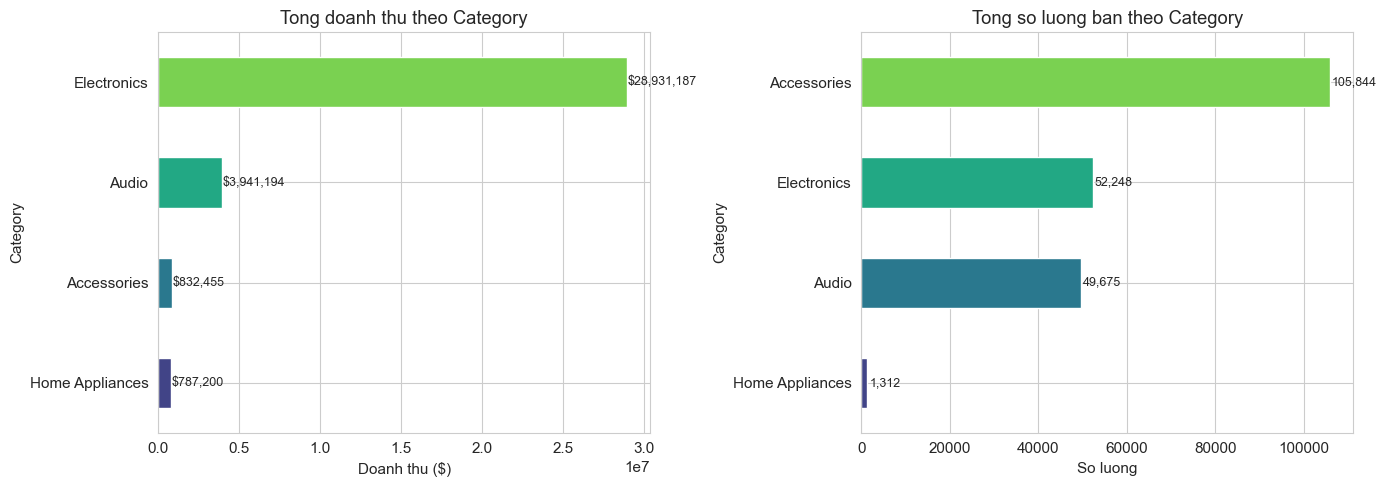

In [9]:
# Doanh thu & so luong theo Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Doanh thu
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
cat_revenue.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(cat_revenue)))
axes[0].set_title('Tong doanh thu theo Category')
axes[0].set_xlabel('Doanh thu ($)')
for i, v in enumerate(cat_revenue):
    axes[0].text(v + 50000, i, f'${v:,.0f}', va='center', fontsize=9)

# So luong
cat_qty = df.groupby('Category')['Quantity Ordered'].sum().sort_values(ascending=True)
cat_qty.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', len(cat_qty)))
axes[1].set_title('Tong so luong ban theo Category')
axes[1].set_xlabel('So luong')
for i, v in enumerate(cat_qty):
    axes[1].text(v + 500, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

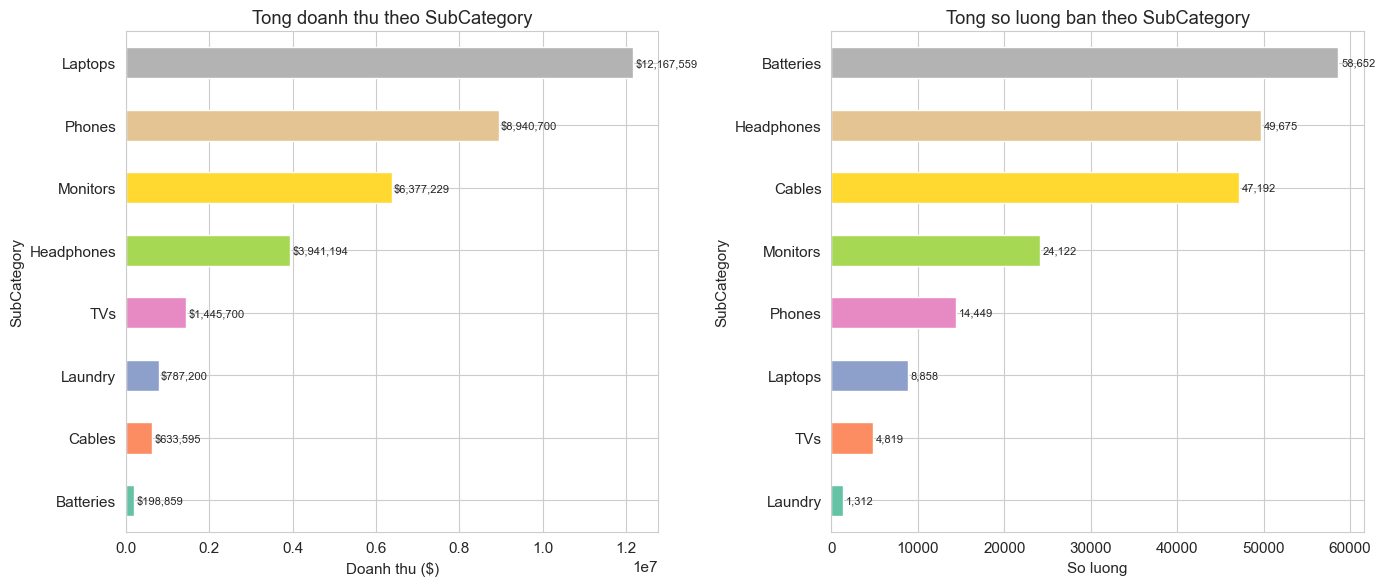

In [10]:
# Doanh thu & so luong theo SubCategory
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

subcat_revenue = df.groupby('SubCategory')['Sales'].sum().sort_values(ascending=True)
colors = sns.color_palette('Set2', len(subcat_revenue))
subcat_revenue.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Tong doanh thu theo SubCategory')
axes[0].set_xlabel('Doanh thu ($)')
for i, v in enumerate(subcat_revenue):
    axes[0].text(v + 50000, i, f'${v:,.0f}', va='center', fontsize=8)

subcat_qty = df.groupby('SubCategory')['Quantity Ordered'].sum().sort_values(ascending=True)
subcat_qty.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Tong so luong ban theo SubCategory')
axes[1].set_xlabel('So luong')
for i, v in enumerate(subcat_qty):
    axes[1].text(v + 300, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

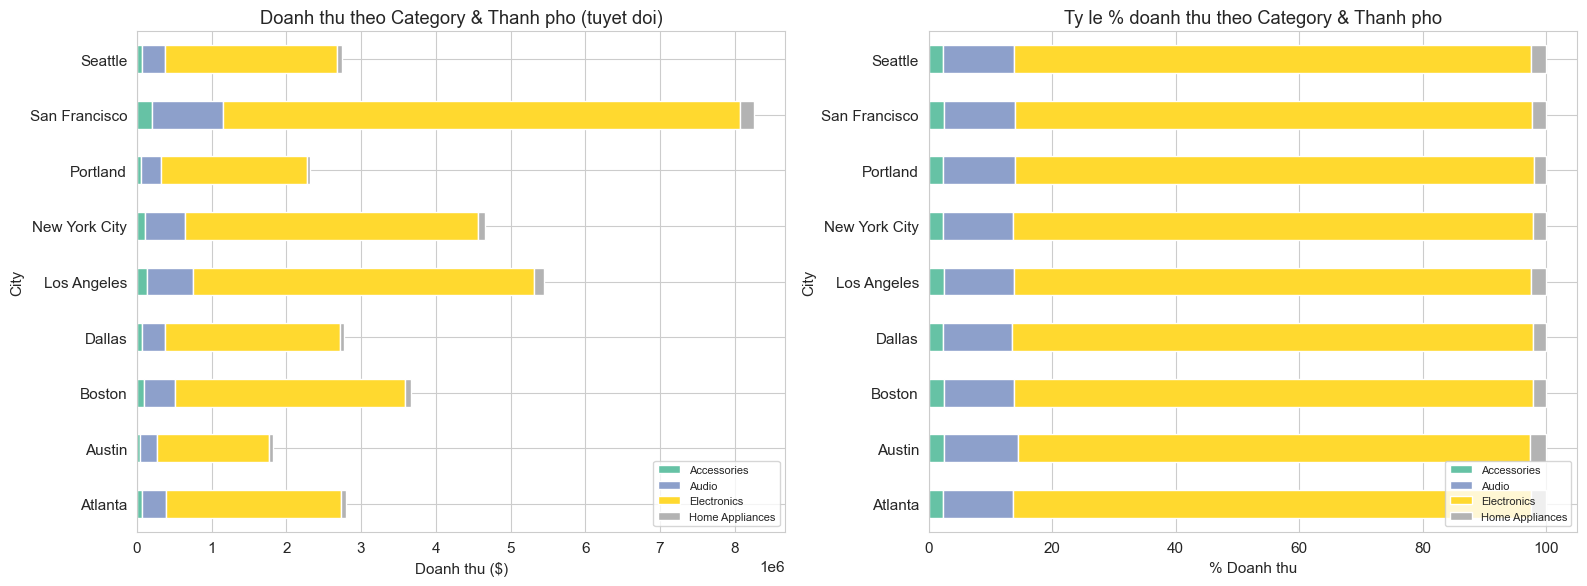

In [11]:
# Phan bo Category theo thanh pho
pivot_city_cat = df.pivot_table(values='Sales', index='City', columns='Category', aggfunc='sum', fill_value=0)

# Normalize theo % de so sanh
pivot_city_cat_pct = pivot_city_cat.div(pivot_city_cat.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_city_cat.plot(kind='barh', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Doanh thu theo Category & Thanh pho (tuyet doi)')
axes[0].set_xlabel('Doanh thu ($)')
axes[0].legend(loc='lower right', fontsize=8)

pivot_city_cat_pct.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Ty le % doanh thu theo Category & Thanh pho')
axes[1].set_xlabel('% Doanh thu')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

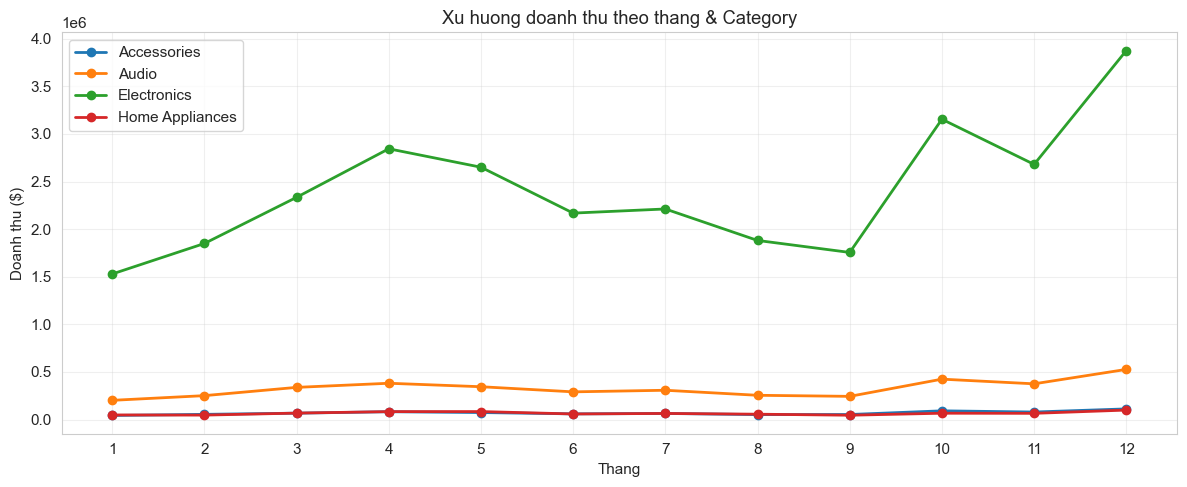

In [12]:
# Xu huong doanh thu theo thang & Category
pivot_month_cat = df.pivot_table(values='Sales', index='Month', columns='Category', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
pivot_month_cat.plot(kind='line', marker='o', ax=ax, linewidth=2)
ax.set_title('Xu huong doanh thu theo thang & Category')
ax.set_xlabel('Thang')
ax.set_ylabel('Doanh thu ($)')
ax.set_xticks(range(1, 13))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Phan 4: Market Basket Analysis — Product Level

Su dung **Apriori Algorithm** de tim frequent itemsets, sau do sinh **Association Rules**.

In [13]:
# Tao basket: nhom san pham theo Order ID
basket = df.groupby('Order ID')['Product'].apply(list).reset_index()
basket.columns = ['Order ID', 'Products']

# Chi giu cac don hang co >= 2 san pham (de phan tich association)
basket_multi = basket[basket['Products'].apply(len) >= 2].copy()
print(f'Tong don hang: {len(basket):,}')
print(f'Don hang co >= 2 san pham: {len(basket_multi):,} ({len(basket_multi)/len(basket)*100:.1f}%)')
print(f'\nVi du 5 don hang dau:')
basket_multi.head()

Tong don hang: 178,437
Don hang co >= 2 san pham: 7,136 (4.0%)

Vi du 5 don hang dau:


,Order ID,Products
41,141275,"[USB-C Charging Cable, Wired Headphones]"
56,141290,"[Apple Airpods Headphones, AA Batteries (4-pack)]"
131,141365,"[Vareebadd Phone, Wired Headphones]"
150,141384,"[Google Phone, USB-C Charging Cable]"
216,141450,"[Google Phone, Bose SoundSport Headphones]"


In [14]:
# One-hot encoding bang TransactionEncoder
# Dung TOAN BO don hang (ca 1 san pham) de tinh support chinh xac
te = TransactionEncoder()
te_array = te.fit_transform(basket['Products'].tolist())
basket_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Basket matrix shape: {basket_encoded.shape}')
print(f'(So don hang x So san pham)')
basket_encoded.head()

Basket matrix shape: (178437, 19)
(So don hang x So san pham)


,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Chay Apriori de tim frequent itemsets
# Ha min_support=0.001 vi chi 4% don hang co nhieu san pham
frequent_items = apriori(basket_encoded, min_support=0.001, use_colnames=True)
frequent_items['itemset_length'] = frequent_items['itemsets'].apply(len)

print(f'Tong so frequent itemsets: {len(frequent_items)}')
print(f'\nPhan bo theo do dai itemset:')
print(frequent_items['itemset_length'].value_counts().sort_index())

print(f'\nTop 20 frequent itemsets (2+ items):')
fi_multi = frequent_items[frequent_items['itemset_length'] >= 2].sort_values('support', ascending=False)
for _, row in fi_multi.head(20).iterrows():
    items = ', '.join(sorted(row['itemsets']))
    print(f'  Support={row["support"]:.4f}  |  {{{items}}}')

In [16]:
# Sinh Association Rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1.0, num_itemsets=len(basket_encoded))

# Chuyen frozenset thanh string de hien thi
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Tong so Association Rules (lift > 1): {len(rules)}')
print(f'\n=== TOP 20 RULES (sap xep theo Lift) ===')
top_rules = rules.sort_values('lift', ascending=False).head(20)
for i, (_, r) in enumerate(top_rules.iterrows(), 1):
    print(f'  {i:2d}. {r["antecedents_str"]:40s} => {r["consequents_str"]:40s}'
          f'  | support={r["support"]:.4f}  conf={r["confidence"]:.3f}  lift={r["lift"]:.2f}')

Tong so Association Rules (lift > 1): 4

=== TOP 20 RULES (sap xep theo Lift) ===
   1. Google Phone                             => USB-C Charging Cable                      | support=0.0056  conf=0.181  lift=1.47
   2. USB-C Charging Cable                     => Google Phone                              | support=0.0056  conf=0.046  lift=1.47
   3. iPhone                                   => Lightning Charging Cable                  | support=0.0057  conf=0.148  lift=1.22
   4. Lightning Charging Cable                 => iPhone                                    | support=0.0057  conf=0.047  lift=1.22


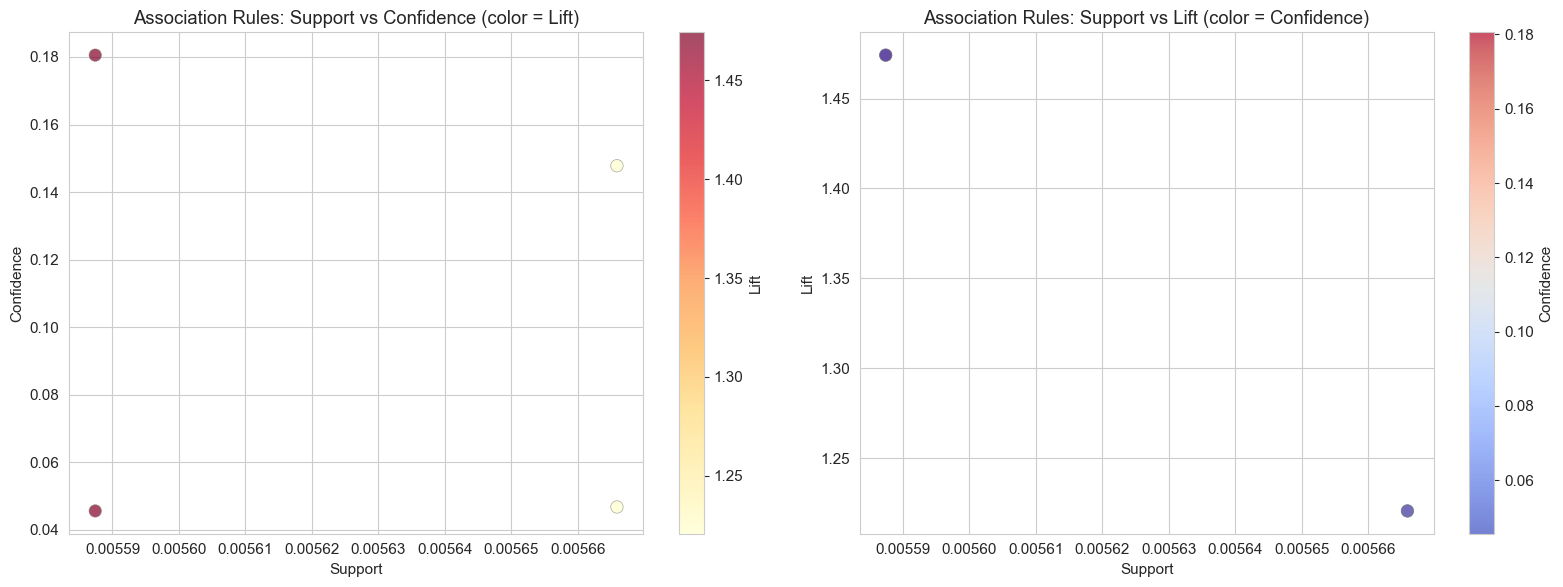

In [17]:
# Visualization: Scatter plot Support vs Confidence, color = Lift
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Support vs Confidence
scatter = axes[0].scatter(rules['support'], rules['confidence'], 
                          c=rules['lift'], cmap='YlOrRd', s=80, 
                          alpha=0.7, edgecolors='gray', linewidth=0.5)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules: Support vs Confidence (color = Lift)')
plt.colorbar(scatter, ax=axes[0], label='Lift')

# Scatter: Support vs Lift
scatter2 = axes[1].scatter(rules['support'], rules['lift'], 
                           c=rules['confidence'], cmap='coolwarm', s=80, 
                           alpha=0.7, edgecolors='gray', linewidth=0.5)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Lift')
axes[1].set_title('Association Rules: Support vs Lift (color = Confidence)')
plt.colorbar(scatter2, ax=axes[1], label='Confidence')

plt.tight_layout()
plt.show()

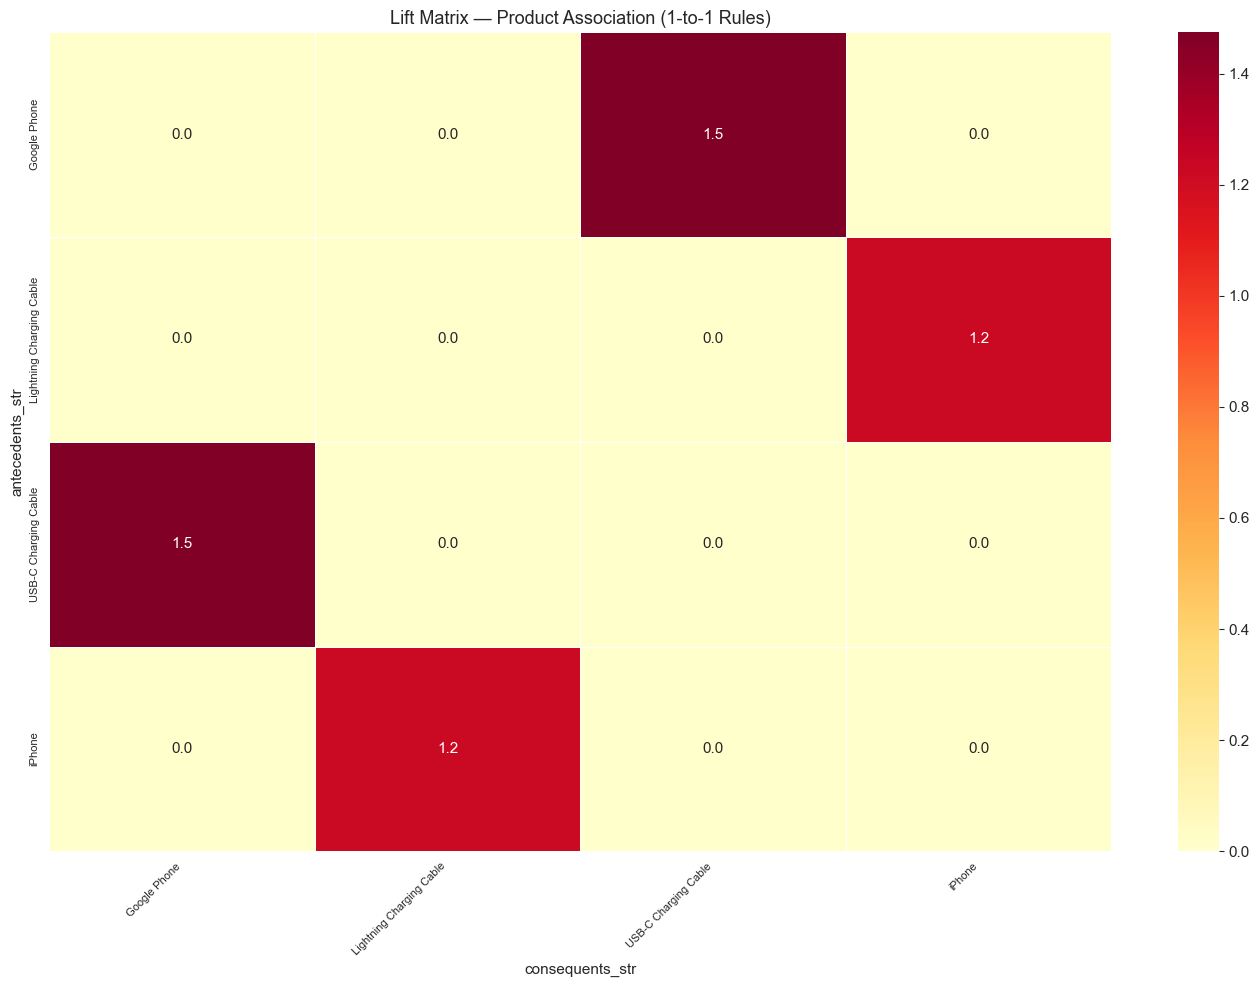

In [18]:
# Heatmap: Lift giua cac san pham (chi rules 1->1)
rules_1to1 = rules[
    (rules['antecedents'].apply(len) == 1) & 
    (rules['consequents'].apply(len) == 1)
].copy()

if len(rules_1to1) > 0:
    pivot_lift = rules_1to1.pivot_table(
        index='antecedents_str', columns='consequents_str', 
        values='lift', fill_value=0
    )
    
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(pivot_lift, annot=True, fmt='.1f', cmap='YlOrRd', 
                linewidths=0.5, ax=ax)
    ax.set_title('Lift Matrix — Product Association (1-to-1 Rules)', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Khong co rules 1-to-1 de ve heatmap.')

---
## Phan 5: Market Basket Analysis — Category / SubCategory Level

Phan tich o cap do Category & SubCategory de co goc nhin tong quat hon.

In [19]:
# Tao basket theo SubCategory
basket_subcat = df.groupby('Order ID')['SubCategory'].apply(lambda x: list(set(x))).reset_index()
basket_subcat.columns = ['Order ID', 'SubCategories']

# Chi don hang co >= 2 SubCategory khac nhau
basket_subcat_multi = basket_subcat[basket_subcat['SubCategories'].apply(len) >= 2]
print(f'Don hang co >= 2 SubCategory khac nhau: {len(basket_subcat_multi):,}')

# One-hot encoding
te_sub = TransactionEncoder()
te_sub_array = te_sub.fit_transform(basket_subcat['SubCategories'].tolist())
basket_sub_encoded = pd.DataFrame(te_sub_array, columns=te_sub.columns_)

print(f'Basket matrix (SubCategory): {basket_sub_encoded.shape}')
basket_sub_encoded.head()

Don hang co >= 2 SubCategory khac nhau: 6,433
Basket matrix (SubCategory): (178437, 8)


,Batteries,Cables,Headphones,Laptops,Laundry,Monitors,Phones,TVs
0,False,False,False,False,False,False,True,False
1,False,True,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,False


In [ ]:
# Apriori cho SubCategory (ha min_support)
freq_subcat = apriori(basket_sub_encoded, min_support=0.001, use_colnames=True)
freq_subcat['itemset_length'] = freq_subcat['itemsets'].apply(len)

print(f'Frequent itemsets (SubCategory): {len(freq_subcat)}')
print(f'\nPhan bo theo do dai:')
print(freq_subcat['itemset_length'].value_counts().sort_index())

print(f'\nTat ca frequent itemsets (2+ items):')
fi_sub_multi = freq_subcat[freq_subcat['itemset_length'] >= 2].sort_values('support', ascending=False)
for _, row in fi_sub_multi.iterrows():
    items = ', '.join(sorted(row['itemsets']))
    print(f'  Support={row["support"]:.4f}  |  {{{items}}}')

# Association Rules — ha min_threshold de hien thi ca rules co lift gan 1
rules_subcat = association_rules(freq_subcat, metric='lift', min_threshold=0.5, num_itemsets=len(basket_sub_encoded))
rules_subcat['antecedents_str'] = rules_subcat['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_subcat['consequents_str'] = rules_subcat['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'\n=== ASSOCIATION RULES — SubCategory Level ===')
print(f'Tong so rules: {len(rules_subcat)}')
print(f'  Trong do lift > 1: {len(rules_subcat[rules_subcat["lift"] > 1])}')
print(f'  Trong do lift <= 1: {len(rules_subcat[rules_subcat["lift"] <= 1])}')

for i, (_, r) in enumerate(rules_subcat.sort_values('lift', ascending=False).iterrows(), 1):
    lift_note = ' *** POSITIVE' if r['lift'] > 1 else ''
    print(f'  {i:2d}. {r["antecedents_str"]:25s} => {r["consequents_str"]:25s}'
          f'  | support={r["support"]:.4f}  conf={r["confidence"]:.3f}  lift={r["lift"]:.2f}{lift_note}')

In [ ]:
# Tao basket theo Category
basket_cat = df.groupby('Order ID')['Category'].apply(lambda x: list(set(x))).reset_index()
basket_cat.columns = ['Order ID', 'Categories']

basket_cat_multi = basket_cat[basket_cat['Categories'].apply(len) >= 2]
print(f'Don hang co >= 2 Category khac nhau: {len(basket_cat_multi):,}')

te_cat = TransactionEncoder()
te_cat_array = te_cat.fit_transform(basket_cat['Categories'].tolist())
basket_cat_encoded = pd.DataFrame(te_cat_array, columns=te_cat.columns_)

# Apriori cho Category
freq_cat = apriori(basket_cat_encoded, min_support=0.001, use_colnames=True)
freq_cat['itemset_length'] = freq_cat['itemsets'].apply(len)

rules_cat = association_rules(freq_cat, metric='lift', min_threshold=0.5, num_itemsets=len(basket_cat_encoded))
rules_cat['antecedents_str'] = rules_cat['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_cat['consequents_str'] = rules_cat['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'\n=== ASSOCIATION RULES — Category Level ===')
print(f'Tong so rules: {len(rules_cat)}')
if len(rules_cat) > 0:
    for i, (_, r) in enumerate(rules_cat.sort_values('lift', ascending=False).iterrows(), 1):
        lift_note = ' *** POSITIVE' if r['lift'] > 1 else ''
        print(f'  {i:2d}. {r["antecedents_str"]:25s} => {r["consequents_str"]:25s}'
              f'  | support={r["support"]:.4f}  conf={r["confidence"]:.3f}  lift={r["lift"]:.2f}{lift_note}')
else:
    print('  Khong tim thay rules. Nguyen nhan: chi 4% don hang co nhieu san pham.')

In [ ]:
# === CO-OCCURRENCE ANALYSIS (bo sung cho Apriori) ===
# Tinh truc tiep tan suat xuat hien cung nhau giua cac SubCategory
from itertools import combinations

# Tinh co-occurrence tu don hang nhieu san pham
subcat_cooccur = Counter()
cat_cooccur = Counter()

for _, row in basket_subcat_multi.iterrows():
    subcats = sorted(set(row['SubCategories']))
    for pair in combinations(subcats, 2):
        subcat_cooccur[pair] += 1

for _, row in basket_cat_multi.iterrows():
    cats = sorted(set(row['Categories']))
    for pair in combinations(cats, 2):
        cat_cooccur[pair] += 1

# --- SubCategory Co-occurrence Heatmap ---
all_subcats = sorted(df['SubCategory'].unique())
cooccur_matrix = pd.DataFrame(0, index=all_subcats, columns=all_subcats)
for (a, b), count in subcat_cooccur.items():
    cooccur_matrix.loc[a, b] = count
    cooccur_matrix.loc[b, a] = count

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cooccur_matrix, annot=True, fmt='d', cmap='Blues', 
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Co-occurrence: SubCategory (so lan mua cung)', fontsize=12)

# --- Category Co-occurrence Heatmap ---
all_cats = sorted(df['Category'].unique())
cat_cooccur_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)
for (a, b), count in cat_cooccur.items():
    cat_cooccur_matrix.loc[a, b] = count
    cat_cooccur_matrix.loc[b, a] = count

sns.heatmap(cat_cooccur_matrix, annot=True, fmt='d', cmap='Greens', 
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Co-occurrence: Category (so lan mua cung)', fontsize=12)

plt.tight_layout()
plt.show()

print('Top 10 cap SubCategory hay mua cung:')
for pair, count in subcat_cooccur.most_common(10):
    print(f'  {pair[0]:15s} + {pair[1]:15s} = {count:,} lan')

print(f'\nTop cap Category hay mua cung:')
for pair, count in cat_cooccur.most_common(10):
    print(f'  {pair[0]:20s} + {pair[1]:20s} = {count:,} lan')

In [ ]:
# Network Graph — xay dung tu co-occurrence data
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- SubCategory Network (tu co-occurrence) ---
G_sub = nx.Graph()
for (a, b), count in subcat_cooccur.items():
    if count >= 50:  # chi hien thi cap co >= 50 lan
        G_sub.add_edge(a, b, weight=count)

if len(G_sub.nodes) > 0:
    pos_sub = nx.spring_layout(G_sub, k=2.5, seed=42)
    edges_sub = G_sub.edges(data=True)
    max_w = max(d['weight'] for _, _, d in edges_sub) if edges_sub else 1
    widths = [d['weight'] / max_w * 8 for _, _, d in edges_sub]
    
    node_sizes = [1200 + G_sub.degree(n) * 300 for n in G_sub.nodes()]
    nx.draw_networkx_nodes(G_sub, pos_sub, ax=axes[0], node_size=node_sizes,
                           node_color='lightblue', edgecolors='gray', linewidths=1.5)
    nx.draw_networkx_labels(G_sub, pos_sub, ax=axes[0], font_size=9, font_weight='bold')
    nx.draw_networkx_edges(G_sub, pos_sub, ax=axes[0], width=widths,
                           edge_color='coral', alpha=0.7)
    edge_labels = {(u, v): f'{d["weight"]}' for u, v, d in edges_sub}
    nx.draw_networkx_edge_labels(G_sub, pos_sub, edge_labels, ax=axes[0], font_size=8)
    axes[0].set_title('Network: SubCategory Co-occurrence (>= 50 lan)', fontsize=12)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Khong du du lieu', ha='center', va='center')
    axes[0].axis('off')

# --- Category Network (tu co-occurrence) ---
G_cat = nx.Graph()
for (a, b), count in cat_cooccur.items():
    G_cat.add_edge(a, b, weight=count)

if len(G_cat.nodes) > 0:
    pos_cat = nx.spring_layout(G_cat, k=2, seed=42)
    edges_cat = G_cat.edges(data=True)
    max_w_cat = max(d['weight'] for _, _, d in edges_cat) if edges_cat else 1
    widths_cat = [d['weight'] / max_w_cat * 10 for _, _, d in edges_cat]
    
    node_sizes_cat = [1500 + G_cat.degree(n) * 500 for n in G_cat.nodes()]
    nx.draw_networkx_nodes(G_cat, pos_cat, ax=axes[1], node_size=node_sizes_cat,
                           node_color='lightgreen', edgecolors='gray', linewidths=1.5)
    nx.draw_networkx_labels(G_cat, pos_cat, ax=axes[1], font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G_cat, pos_cat, ax=axes[1], width=widths_cat,
                           edge_color='steelblue', alpha=0.7)
    edge_labels_cat = {(u, v): f'{d["weight"]}' for u, v, d in edges_cat}
    nx.draw_networkx_edge_labels(G_cat, pos_cat, edge_labels_cat, ax=axes[1], font_size=9)
    axes[1].set_title('Network: Category Co-occurrence', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Phan 6: Tong ket & Khuyen nghi

In [ ]:
# Bang tong hop rules quan trong nhat
print('=' * 90)
print('TONG KET KET QUA PHAN TICH')
print('=' * 90)

print(f'\n1. NLP PRODUCT CLASSIFICATION')
print(f'   - 19 san pham da phan loai thanh cong vao 4 Category, 8 SubCategory')
print(f'   - Phuong phap: Tokenization + Keyword-based Rule Classification + TF-IDF Validation')

print(f'\n2. MARKET BASKET ANALYSIS — PRODUCT LEVEL')
print(f'   - Tong don hang phan tich: {len(basket):,}')
print(f'   - Don hang co >= 2 san pham: {len(basket_multi):,} ({len(basket_multi)/len(basket)*100:.1f}%)')
print(f'   - Tong so Association Rules (lift>1): {len(rules[rules["lift"]>1])}')

if len(rules) > 0:
    print(f'\n   TOP 10 RULES (theo Lift):')
    for i, (_, r) in enumerate(rules.sort_values('lift', ascending=False).head(10).iterrows(), 1):
        print(f'   {i:2d}. {r["antecedents_str"]} => {r["consequents_str"]}')
        print(f'       Support={r["support"]:.4f}  Confidence={r["confidence"]:.3f}  Lift={r["lift"]:.2f}')

print(f'\n3. MARKET BASKET ANALYSIS — SUBCATEGORY LEVEL')
print(f'   - Tong so rules: {len(rules_subcat)}')
print(f'   - Rules voi lift > 1: {len(rules_subcat[rules_subcat["lift"]>1])}')
if len(rules_subcat) > 0:
    print(f'\n   TOP RULES:')
    for i, (_, r) in enumerate(rules_subcat.sort_values('lift', ascending=False).head(5).iterrows(), 1):
        print(f'   {i}. {r["antecedents_str"]} => {r["consequents_str"]}')
        print(f'      Support={r["support"]:.4f}  Confidence={r["confidence"]:.3f}  Lift={r["lift"]:.2f}')

print(f'\n4. CO-OCCURRENCE ANALYSIS')
print(f'   Top 5 SubCategory hay mua cung:')
for pair, count in subcat_cooccur.most_common(5):
    print(f'   - {pair[0]} + {pair[1]}: {count:,} lan')
print(f'\n   Top Category hay mua cung:')
for pair, count in cat_cooccur.most_common(5):
    print(f'   - {pair[0]} + {pair[1]}: {count:,} lan')

print(f'\n5. KEY INSIGHT')
print(f'   - Chi 4% don hang co >= 2 san pham -> ty le cross-buy thap')
print(f'   - Lien ket manh nhat: Phone + Cable (cap sac di kem dien thoai)')
print(f'   - Electronics + Accessories la cap Category co co-occurrence cao nhat')
print(f'   - Home Appliances gan nhu doc lap, it lien ket voi nhom khac')
print(f'\n{"=" * 90}')

### Khuyen nghi chien luoc

**1. Cross-sell / Up-sell:**
- Dua tren association rules co lift cao nhat, khi khach mua dien thoai (iPhone, Google Phone), 
  nen goi y them cap sac (Lightning/USB-C) va tai nghe (Wired/Bose/Airpods)
- Day la moi lien ket tu nhien: phone + phu kien

**2. Bundling (goi san pham):**
- Tao combo: Phone + Cable + Headphones voi gia uu dai
- Goi "phu kien thiet yeu" cho tung dong dien thoai

**3. Category-level insight:**
- Electronics (dien tu) va Accessories (phu kien) co moi lien ket manh nhat
- Audio (am thanh) thuong di kem voi Electronics
- Home Appliances (do gia dung) it lien ket — co the can chien luoc rieng

**4. Layout cua hang / website:**
- Dat san pham phu kien (cap, pin, tai nghe) gan khu vuc dien thoai & laptop
- Trang san pham nen co phan "Thuong mua cung" dua tren association rules